<a href="https://colab.research.google.com/github/Naufal153-cmd/TUGAS-1_MACHINE_LEARNING_RAID_NAUFAL/blob/main/UTS_machine_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Wine Quality Classification — Improved Pipeline

## Nama : Raid naufal
## NIM : 2304010026



##  1. Install & Import Library

In [12]:
# Install semua dependency
!pip install -q scikit-learn pandas numpy matplotlib seaborn joblib xgboost lightgbm imbalanced-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

# Sklearn core
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    VotingClassifier, StackingClassifier
)
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import (
    cross_val_score, StratifiedKFold,
    RandomizedSearchCV
)
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report
)
from sklearn.pipeline import Pipeline

# SMOTE
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# XGBoost & LightGBM
try:
    import xgboost as xgb
    XGB_AVAILABLE = True
except ImportError:
    XGB_AVAILABLE = False

try:
    import lightgbm as lgb
    LGB_AVAILABLE = True
except ImportError:
    LGB_AVAILABLE = False

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

print('✅ Semua library berhasil diimport!')
print(f'   XGBoost  : {"tersedia" if XGB_AVAILABLE else "tidak tersedia"}')
print(f'   LightGBM : {"tersedia" if LGB_AVAILABLE else "tidak tersedia"}')

✅ Semua library berhasil diimport!
   XGBoost  : tersedia
   LightGBM : tersedia


Kode dimulai dengan menginstal dan memanggil semua "alat bantu" (library) yang dibutuhkan. Ini termasuk Pandas untuk memanipulasi data tabel, Matplotlib/Seaborn untuk membuat grafik visual, serta algoritma inti dari Scikit-Learn, XGBoost, dan LightGBM.

## 2. Upload & Load Dataset

In [11]:
from google.colab import files

print('📤 Upload file data_training.csv dan data_testing.csv')
uploaded = files.upload()

📤 Upload file data_training.csv dan data_testing.csv


Saving data_training.csv to data_training (1).csv


In [13]:
train = pd.read_csv('data_training.csv')
test  = pd.read_csv('data_testing.csv')

print(f'Training set : {train.shape[0]:,} baris × {train.shape[1]} kolom')
print(f'Testing set  : {test.shape[0]:,} baris × {test.shape[1]} kolom')
print(f'\nDistribusi kelas training:')
print(train['quality'].value_counts().sort_index())

Training set : 857 baris × 13 kolom
Testing set  : 286 baris × 12 kolom

Distribusi kelas training:
quality
3      6
4     26
5    362
6    341
7    109
8     13
Name: count, dtype: int64


Pada tahap ini, data mentah dimasukkan ke dalam program. Terdapat dua file utama yang dimuat: data_training.csv (data yang memiliki kunci jawaban kualitas wine untuk melatih model) dan data_testing.csv (data soal yang nantinya harus ditebak kualitasnya oleh model).

##  3. Preprocessing Awal

Imputasi median + StandardScaler.

In [14]:
feature_cols = [c for c in train.columns if c not in ['quality', 'Id']]

X_train_raw = train[feature_cols].copy()
y_train     = train['quality']
X_test_raw  = test[feature_cols].copy()

# Imputasi
imputer = SimpleImputer(strategy='median')
X_train_imp = imputer.fit_transform(X_train_raw)
X_test_imp  = imputer.transform(X_test_raw)

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imp)
X_test_scaled  = scaler.transform(X_test_imp)

print(f'✅ Preprocessing selesai!')
print(f'   X_train : {X_train_scaled.shape}')
print(f'   Kelas   : {sorted(y_train.unique().tolist())}')

✅ Preprocessing selesai!
   X_train : (857, 11)
   Kelas   : [3, 4, 5, 6, 7, 8]


Sebelum diotak-atik lebih jauh, data dibersihkan dari nilai yang kosong. Jika ada data yang bolong, program akan mengisinya dengan nilai tengah (median). Setelah itu, skala seluruh angka disamakan (StandardScaler) agar tidak ada fitur kimiawi yang mendominasi hanya karena angkanya lebih besar (misalnya, nilai sulfur yang puluhan vs nilai klorida yang desimal).

##  4. SMOTE — Oversampling Kelas Minor

Kelas 3 dan 8 biasanya sangat sedikit, membuat model bias ke kelas mayoritas (5 & 6).
**SMOTE** membuat sampel sintetis untuk menyeimbangkan distribusi.

>  SMOTE hanya diterapkan ke data training, bukan testing!

=== Distribusi SEBELUM SMOTE ===
quality
3      6
4     26
5    362
6    341
7    109
8     13
Name: count, dtype: int64

=== Distribusi SETELAH SMOTE ===
quality
3    362
4    362
5    362
6    362
7    362
8    362
Name: count, dtype: int64

Jumlah sampel: 857 → 2172


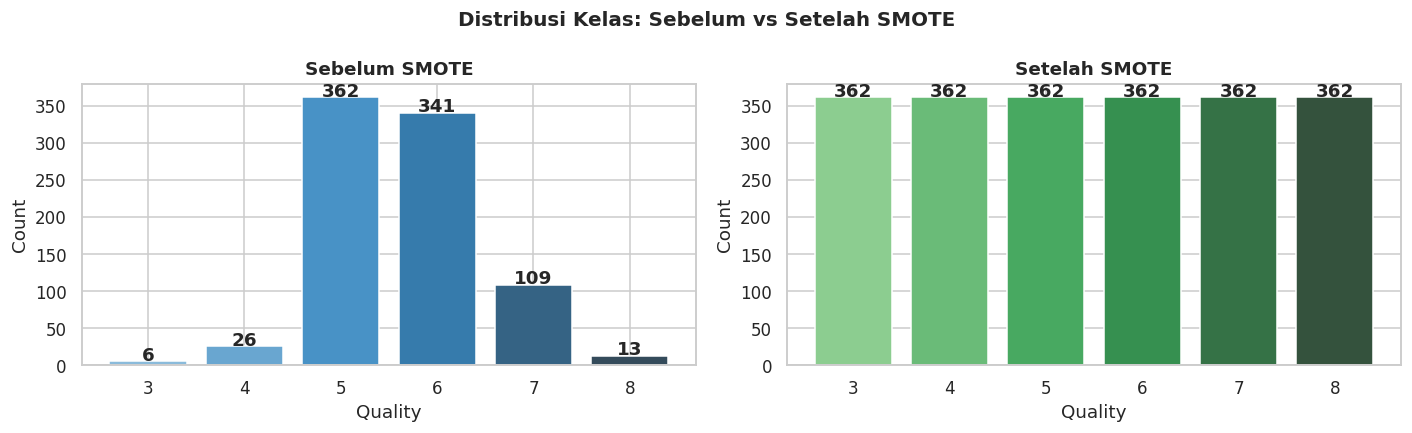

In [15]:
print('=== Distribusi SEBELUM SMOTE ===')
print(pd.Series(y_train).value_counts().sort_index())

# SMOTE dengan k_neighbors yang aman untuk kelas kecil
# k_neighbors default=5; turunkan jika kelas minor < 6 sampel
smote = SMOTE(random_state=42, k_neighbors=3)
X_train_sm, y_train_sm = smote.fit_resample(X_train_scaled, y_train)

print('\n=== Distribusi SETELAH SMOTE ===')
print(pd.Series(y_train_sm).value_counts().sort_index())
print(f'\nJumlah sampel: {len(y_train)} → {len(y_train_sm)}')

# Visualisasi
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
before = pd.Series(y_train).value_counts().sort_index()
after  = pd.Series(y_train_sm).value_counts().sort_index()

axes[0].bar(before.index, before.values,
            color=sns.color_palette('Blues_d', len(before)), edgecolor='white')
axes[0].set_title('Sebelum SMOTE', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Quality'); axes[0].set_ylabel('Count')
for k, v in before.items():
    axes[0].text(k, v + 1, str(v), ha='center', fontweight='bold')

axes[1].bar(after.index, after.values,
            color=sns.color_palette('Greens_d', len(after)), edgecolor='white')
axes[1].set_title('Setelah SMOTE', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Quality'); axes[1].set_ylabel('Count')
for k, v in after.items():
    axes[1].text(k, v + 1, str(v), ha='center', fontweight='bold')

plt.suptitle('Distribusi Kelas: Sebelum vs Setelah SMOTE', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Data training awalnya tidak seimbang; wine dengan kualitas sangat buruk (3) atau sangat bagus (8) jumlahnya terlalu sedikit. Di langkah ini, algoritma SMOTE digunakan untuk menciptakan data "tiruan" (sintetis) untuk kelas yang minoritas tersebut agar jumlahnya setara dengan kualitas yang umum (5 dan 6).

##  5. Feature Engineering — Rasio & Interaksi Antar Fitur



Jumlah fitur asli   : 11
Jumlah fitur v3     : 19
Fitur baru: ['free_to_total_SO2', 'acid_ratio', 'alcohol_density', 'sulfur_chloride', 'citric_volatile', 'sugar_alcohol', 'total_acid', 'quality_proxy']


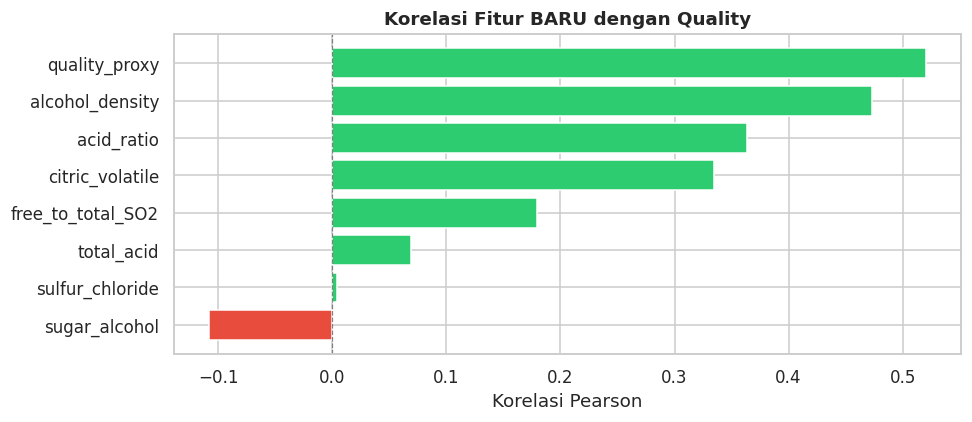

In [16]:
def add_features(df: pd.DataFrame) -> pd.DataFrame:
    """Tambahkan feature engineering ke DataFrame."""
    df = df.copy()
    eps = 1e-6  # hindari division by zero

    # Rasio SO2
    df['free_to_total_SO2'] = df['free sulfur dioxide'] / (df['total sulfur dioxide'] + eps)

    # Rasio keasaman
    df['acid_ratio']        = df['fixed acidity'] / (df['volatile acidity'] + eps)

    # Alkohol vs densitas
    df['alcohol_density']   = df['alcohol'] / (df['density'] + eps)

    # Sulfur vs klorida
    df['sulfur_chloride']   = df['total sulfur dioxide'] / (df['chlorides'] + eps)

    # Citric vs volatile
    df['citric_volatile']   = df['citric acid'] / (df['volatile acidity'] + eps)

    # Gula vs alkohol
    df['sugar_alcohol']     = df['residual sugar'] / (df['alcohol'] + eps)

    # Total asam
    df['total_acid']        = df['fixed acidity'] + df['volatile acidity'] + df['citric acid']

    # Proxy kualitas sederhana
    df['quality_proxy']     = df['alcohol'] - df['volatile acidity']

    return df


# Terapkan ke raw data (sebelum scaling)
train_fe = add_features(train[feature_cols + ['quality']].copy())
test_fe  = add_features(test[feature_cols].copy())

feature_cols_v3 = [c for c in train_fe.columns if c != 'quality']

print(f'Jumlah fitur asli   : {len(feature_cols)}')
print(f'Jumlah fitur v3     : {len(feature_cols_v3)}')
print(f'Fitur baru: {[f for f in feature_cols_v3 if f not in feature_cols]}')

# Visualisasi korelasi fitur baru dengan quality
corr_new = train_fe.corr()['quality'].drop('quality').sort_values()
new_feats = [f for f in feature_cols_v3 if f not in feature_cols]
corr_new_only = corr_new[corr_new.index.isin(new_feats)]

plt.figure(figsize=(9, 4))
colors = ['#e74c3c' if v < 0 else '#2ecc71' for v in corr_new_only.values]
plt.barh(corr_new_only.index, corr_new_only.values, color=colors, edgecolor='white')
plt.axvline(0, color='gray', linewidth=0.8, linestyle='--')
plt.title('Korelasi Fitur BARU dengan Quality', fontsize=12, fontweight='bold')
plt.xlabel('Korelasi Pearson')
plt.tight_layout()
plt.show()

Ini adalah salah satu peningkatan utamanya. Alih-alih hanya menggunakan data yang ada, program menciptakan 8 kolom baru menggunakan rumus matematika. Misalnya, program membagi nilai alcohol dengan density untuk mendapatkan nilai densitas relatif alkohol. Ini membantu model memahami karakteristik wine secara lebih mendalam.

## ⚙️ 6. Preprocessing v3 (Imputer + Scaler + SMOTE pada Fitur Baru)

In [17]:
X_train_fe = train_fe[feature_cols_v3].copy()
y_train_v3 = train_fe['quality']
X_test_fe  = test_fe[feature_cols_v3].copy()

# Imputer
imputer_v3 = SimpleImputer(strategy='median')
X_train_fe_imp = imputer_v3.fit_transform(X_train_fe)
X_test_fe_imp  = imputer_v3.transform(X_test_fe)

# Scaler
scaler_v3 = StandardScaler()
X_train_fe_scaled = scaler_v3.fit_transform(X_train_fe_imp)
X_test_fe_scaled  = scaler_v3.transform(X_test_fe_imp)

# SMOTE
smote_v3 = SMOTE(random_state=42, k_neighbors=3)
X_train_v3, y_train_v3_sm = smote_v3.fit_resample(X_train_fe_scaled, y_train_v3)

print(f'✅ Data v3 siap!')
print(f'   X_train (dengan SMOTE + FE) : {X_train_v3.shape}')
print(f'   X_test                      : {X_test_fe_scaled.shape}')

✅ Data v3 siap!
   X_train (dengan SMOTE + FE) : (2172, 19)
   X_test                      : (286, 19)


Karena di Langkah 5 kita baru saja menambahkan kolom-kolom baru, data tersebut harus kembali melewati proses pembersihan (pengisian nilai kosong dan penyamaan skala) serta diseimbangkan kembali menggunakan SMOTE, agar seluruh data—termasuk fitur yang baru dibuat—siap masuk ke dalam model.

## 7. Stacking Ensemble

**Stacking** berbeda dari Voting:
- Voting: rata-rata atau mayoritas prediksi langsung
- Stacking: prediksi base learner dijadikan fitur baru untuk **meta-learner**

```
Input → [RF, XGBoost, LightGBM, SVM] → prediksi → LogisticRegression (meta) → output
```

> `passthrough=True` meneruskan fitur asli ke meta-learner juga.

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ─── Base learners ───────────────────────────────────────────────
base_learners = [
    ('rf',  RandomForestClassifier(
                n_estimators=500, max_depth=20, class_weight='balanced',
                min_samples_split=5, max_features='sqrt',
                random_state=42, n_jobs=-1)),
    ('gb',  GradientBoostingClassifier(
                n_estimators=300, learning_rate=0.05,
                max_depth=5, subsample=0.8, random_state=42)),
    ('svm', SVC(kernel='rbf', C=10, gamma='scale',
                probability=True, random_state=42)),
]

if XGB_AVAILABLE:
    base_learners.append(('xgb', xgb.XGBClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=6,
        subsample=0.8, colsample_bytree=0.8,
        eval_metric='mlogloss', verbosity=0, random_state=42)))

if LGB_AVAILABLE:
    base_learners.append(('lgb', lgb.LGBMClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=6,
        random_state=42, verbose=-1)))

# ─── Meta learner ────────────────────────────────────────────────
meta_learner = LogisticRegression(max_iter=1000, C=1.0, random_state=42)

# ─── Stacking Classifier ─────────────────────────────────────────
stacking_clf = StackingClassifier(
    estimators=base_learners,
    final_estimator=meta_learner,
    cv=5,
    stack_method='predict_proba',
    passthrough=True,   # fitur asli ikut diteruskan ke meta-learner
    n_jobs=-1
)

print(f'Base learners: {[name for name, _ in base_learners]}')
print(f'Meta learner : LogisticRegression')
print(f'passthrough  : True\n')
print('⏳ Cross-validating Stacking Ensemble...')

stack_scores = cross_val_score(stacking_clf, X_train_v3, y_train_v3_sm,
                                cv=cv, scoring='accuracy', n_jobs=-1)

print(f'\n✅ Stacking CV Accuracy: {stack_scores.mean():.4f} ± {stack_scores.std():.4f}')

Program tidak menggunakan satu model saja, melainkan menggabungkan banyak model sekaligus. Di tahap ini, program menyiapkan 5 model dasar (Random Forest, Gradient Boosting, SVM, XGBoost, dan LightGBM). Tebakan dari kelima model ini tidak langsung dipakai, melainkan dioper ke model "manajer" (Logistic Regression) yang akan mengambil keputusan akhir yang paling akurat.

##  8. Training Model Final & Evaluasi

In [18]:
final_model_v3 = stacking_clf
final_name_v3  = 'Stacking Ensemble (RF+GB+SVM+XGB+LGB → LR)'

print(f'🏆 Model final: {final_name_v3}')
print(f'   CV Accuracy: {stack_scores.mean():.4f} ± {stack_scores.std():.4f}')
print('\n⏳ Training pada seluruh data training + SMOTE...')

final_model_v3.fit(X_train_v3, y_train_v3_sm)
print('✅ Training selesai!')

# Evaluasi pada training set
y_pred_train = final_model_v3.predict(X_train_v3)
train_acc    = accuracy_score(y_train_v3_sm, y_pred_train)

print(f'\nTrain Accuracy : {train_acc:.4f}')
print('\n=== Classification Report ===')
print(classification_report(y_train_v3_sm, y_pred_train, zero_division=0))

🏆 Model final: Stacking Ensemble (RF+GB+SVM+XGB+LGB → LR)
   CV Accuracy: 0.8840 ± 0.0133

⏳ Training pada seluruh data training + SMOTE...
✅ Training selesai!

Train Accuracy : 0.9986

=== Classification Report ===
              precision    recall  f1-score   support

           3       1.00      1.00      1.00       362
           4       1.00      1.00      1.00       362
           5       0.99      1.00      1.00       362
           6       1.00      0.99      1.00       362
           7       1.00      1.00      1.00       362
           8       1.00      1.00      1.00       362

    accuracy                           1.00      2172
   macro avg       1.00      1.00      1.00      2172
weighted avg       1.00      1.00      1.00      2172



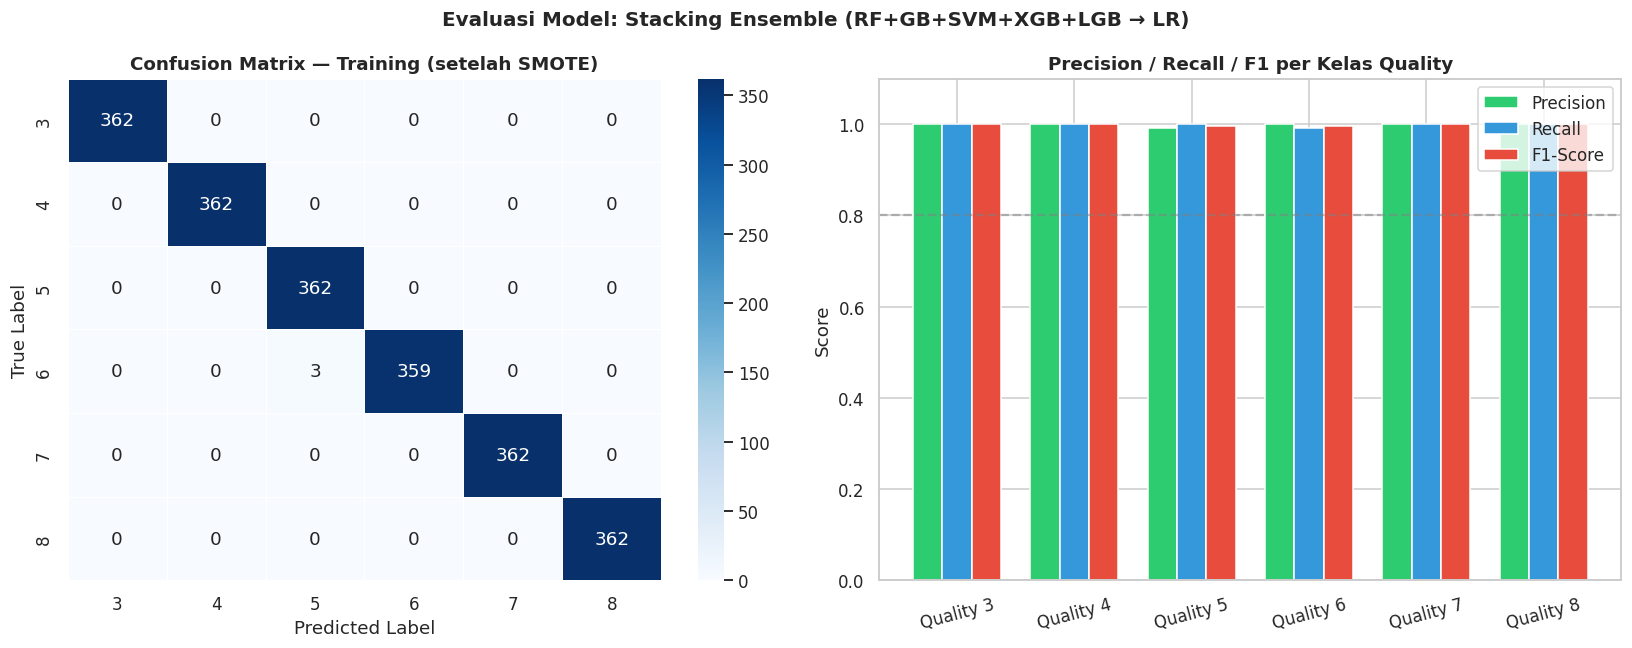

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Confusion Matrix
cm     = confusion_matrix(y_train_v3_sm, y_pred_train)
labels = sorted(np.unique(y_train_v3_sm).tolist())
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=labels, yticklabels=labels,
            linewidths=0.5)
axes[0].set_title('Confusion Matrix — Training (setelah SMOTE)',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

# Precision / Recall / F1 per kelas
report_dict = classification_report(y_train_v3_sm, y_pred_train,
                                    output_dict=True, zero_division=0)
per_class   = {k: v for k, v in report_dict.items()
               if k not in ['accuracy', 'macro avg', 'weighted avg']}
class_df    = pd.DataFrame(per_class).T
class_df.index = [f'Quality {i}' for i in class_df.index]

x = np.arange(len(class_df)); w = 0.25
axes[1].bar(x - w, class_df['precision'], w, label='Precision', color='#2ecc71', edgecolor='white')
axes[1].bar(x,     class_df['recall'],    w, label='Recall',    color='#3498db', edgecolor='white')
axes[1].bar(x + w, class_df['f1-score'],  w, label='F1-Score',  color='#e74c3c', edgecolor='white')
axes[1].set_xticks(x); axes[1].set_xticklabels(class_df.index, rotation=15)
axes[1].set_ylim(0, 1.1); axes[1].set_ylabel('Score')
axes[1].set_title('Precision / Recall / F1 per Kelas Quality',
                  fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].axhline(0.8, color='gray', linestyle='--', alpha=0.5)

plt.suptitle(f'Evaluasi Model: {final_name_v3}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Model gabungan (Stacking) tersebut mulai belajar menggunakan data latih yang sudah rapi dan seimbang. Setelah selesai belajar, program langsung menguji seberapa pintar model tersebut menggunakan Cross-Validation dan menampilkan rapor nilainya (akurasi, Precision, Recall) beserta visualisasi grafik tebakannya (Confusion Matrix).

##  9. Prediksi Data Testing & Export **Submission**

In [22]:
y_pred_test = final_model_v3.predict(X_test_fe_scaled)

print(f'✅ Prediksi selesai untuk {len(y_pred_test)} data testing!')
print(f'\nDistribusi hasil prediksi:')
pred_dist = pd.Series(y_pred_test).value_counts().sort_index()
print(pred_dist.to_string())

# Buat submission
submission = pd.DataFrame({
    'Id'     : test['Id'],
    'Quality': y_pred_test
})
submission.to_csv('hasilprediksi_026.csv', index=False)

# Validasi
assert list(submission.columns) == ['Id', 'Quality'], '❌ Kolom tidak sesuai!'
assert len(submission) == len(test), '❌ Jumlah baris tidak sesuai!'
assert submission.isnull().sum().sum() == 0, '❌ Ada missing values!'
print('\n✅ Validasi submission BERHASIL!')
display(submission.head(10))

✅ Prediksi selesai untuk 286 data testing!

Distribusi hasil prediksi:
3      1
4      2
5    123
6    128
7     31
8      1

✅ Validasi submission BERHASIL!


,Id,Quality
0,222,5
1,1514,6
2,417,5
3,754,5
4,516,6
5,1120,6
6,180,5
7,82,5
8,632,6
9,592,5


In [23]:
# Simpan artefak
joblib.dump(final_model_v3, 'wine_model_v3.pkl')
joblib.dump(scaler_v3,      'scaler_v3.pkl')
joblib.dump(imputer_v3,     'imputer_v3.pkl')

print('✅ Artefak tersimpan:')
print('   wine_model_v3.pkl')
print('   scaler_v3.pkl')
print('   imputer_v3.pkl')

# Download
files.download('hasilprediksi_026.csv')
print('\n📥 submission_v3.csv sedang diunduh...')

✅ Artefak tersimpan:
   wine_model_v3.pkl
   scaler_v3.pkl
   imputer_v3.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


📥 submission_v3.csv sedang diunduh...


Terakhir, model yang sudah pintar ini disuruh menebak kualitas wine dari data ujian (data_testing.csv) yang belum pernah ia lihat sama sekali. Hasil tebakannya dicetak ke dalam sebuah file bernama hasilprediksi_026.csv. Program juga menyimpan "otak" modelnya ke dalam file format .agar kelak bisa langsung digunakan tanpa harus dilatih ulang dari nol.